In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['hatch.linewidth'] = 0.5

['/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf']


[(np.float64(0.5529411764705883), np.float64(0.8274509803921568), np.float64(0.7803921568627451), np.float64(1.0)), (np.float64(1.0), np.float64(1.0), np.float64(0.7019607843137254), np.float64(1.0)), (np.float64(0.7450980392156863), np.float64(0.7294117647058823), np.float64(0.8549019607843137), np.float64(1.0)), (np.float64(0.5019607843137255), np.float64(0.6941176470588235), np.float64(0.8274509803921568), np.float64(1.0)), (np.float64(0.9921568627450981), np.float64(0.7058823529411765), np.float64(0.3843137254901961), np.float64(1.0)), (np.float64(0.7019607843137254), np.float64(0.8705882352941177), np.float64(0.4117647058823529), np.float64(1.0)), (np.float64(0.8509803921568627), np.float64(0.8509803921568627), np.float64(0.8509803921568627), np.float64(1.0)), (np.float64(0.7372549019607844), np.float64(0.5019607843137255), np.float64(0.7411764705882353), np.float64(1.0)), (np.float64(0.8), np.float64(0.9215686274509803), np.float64(0.7725490196078432), np.float64(1.0)), (np.float

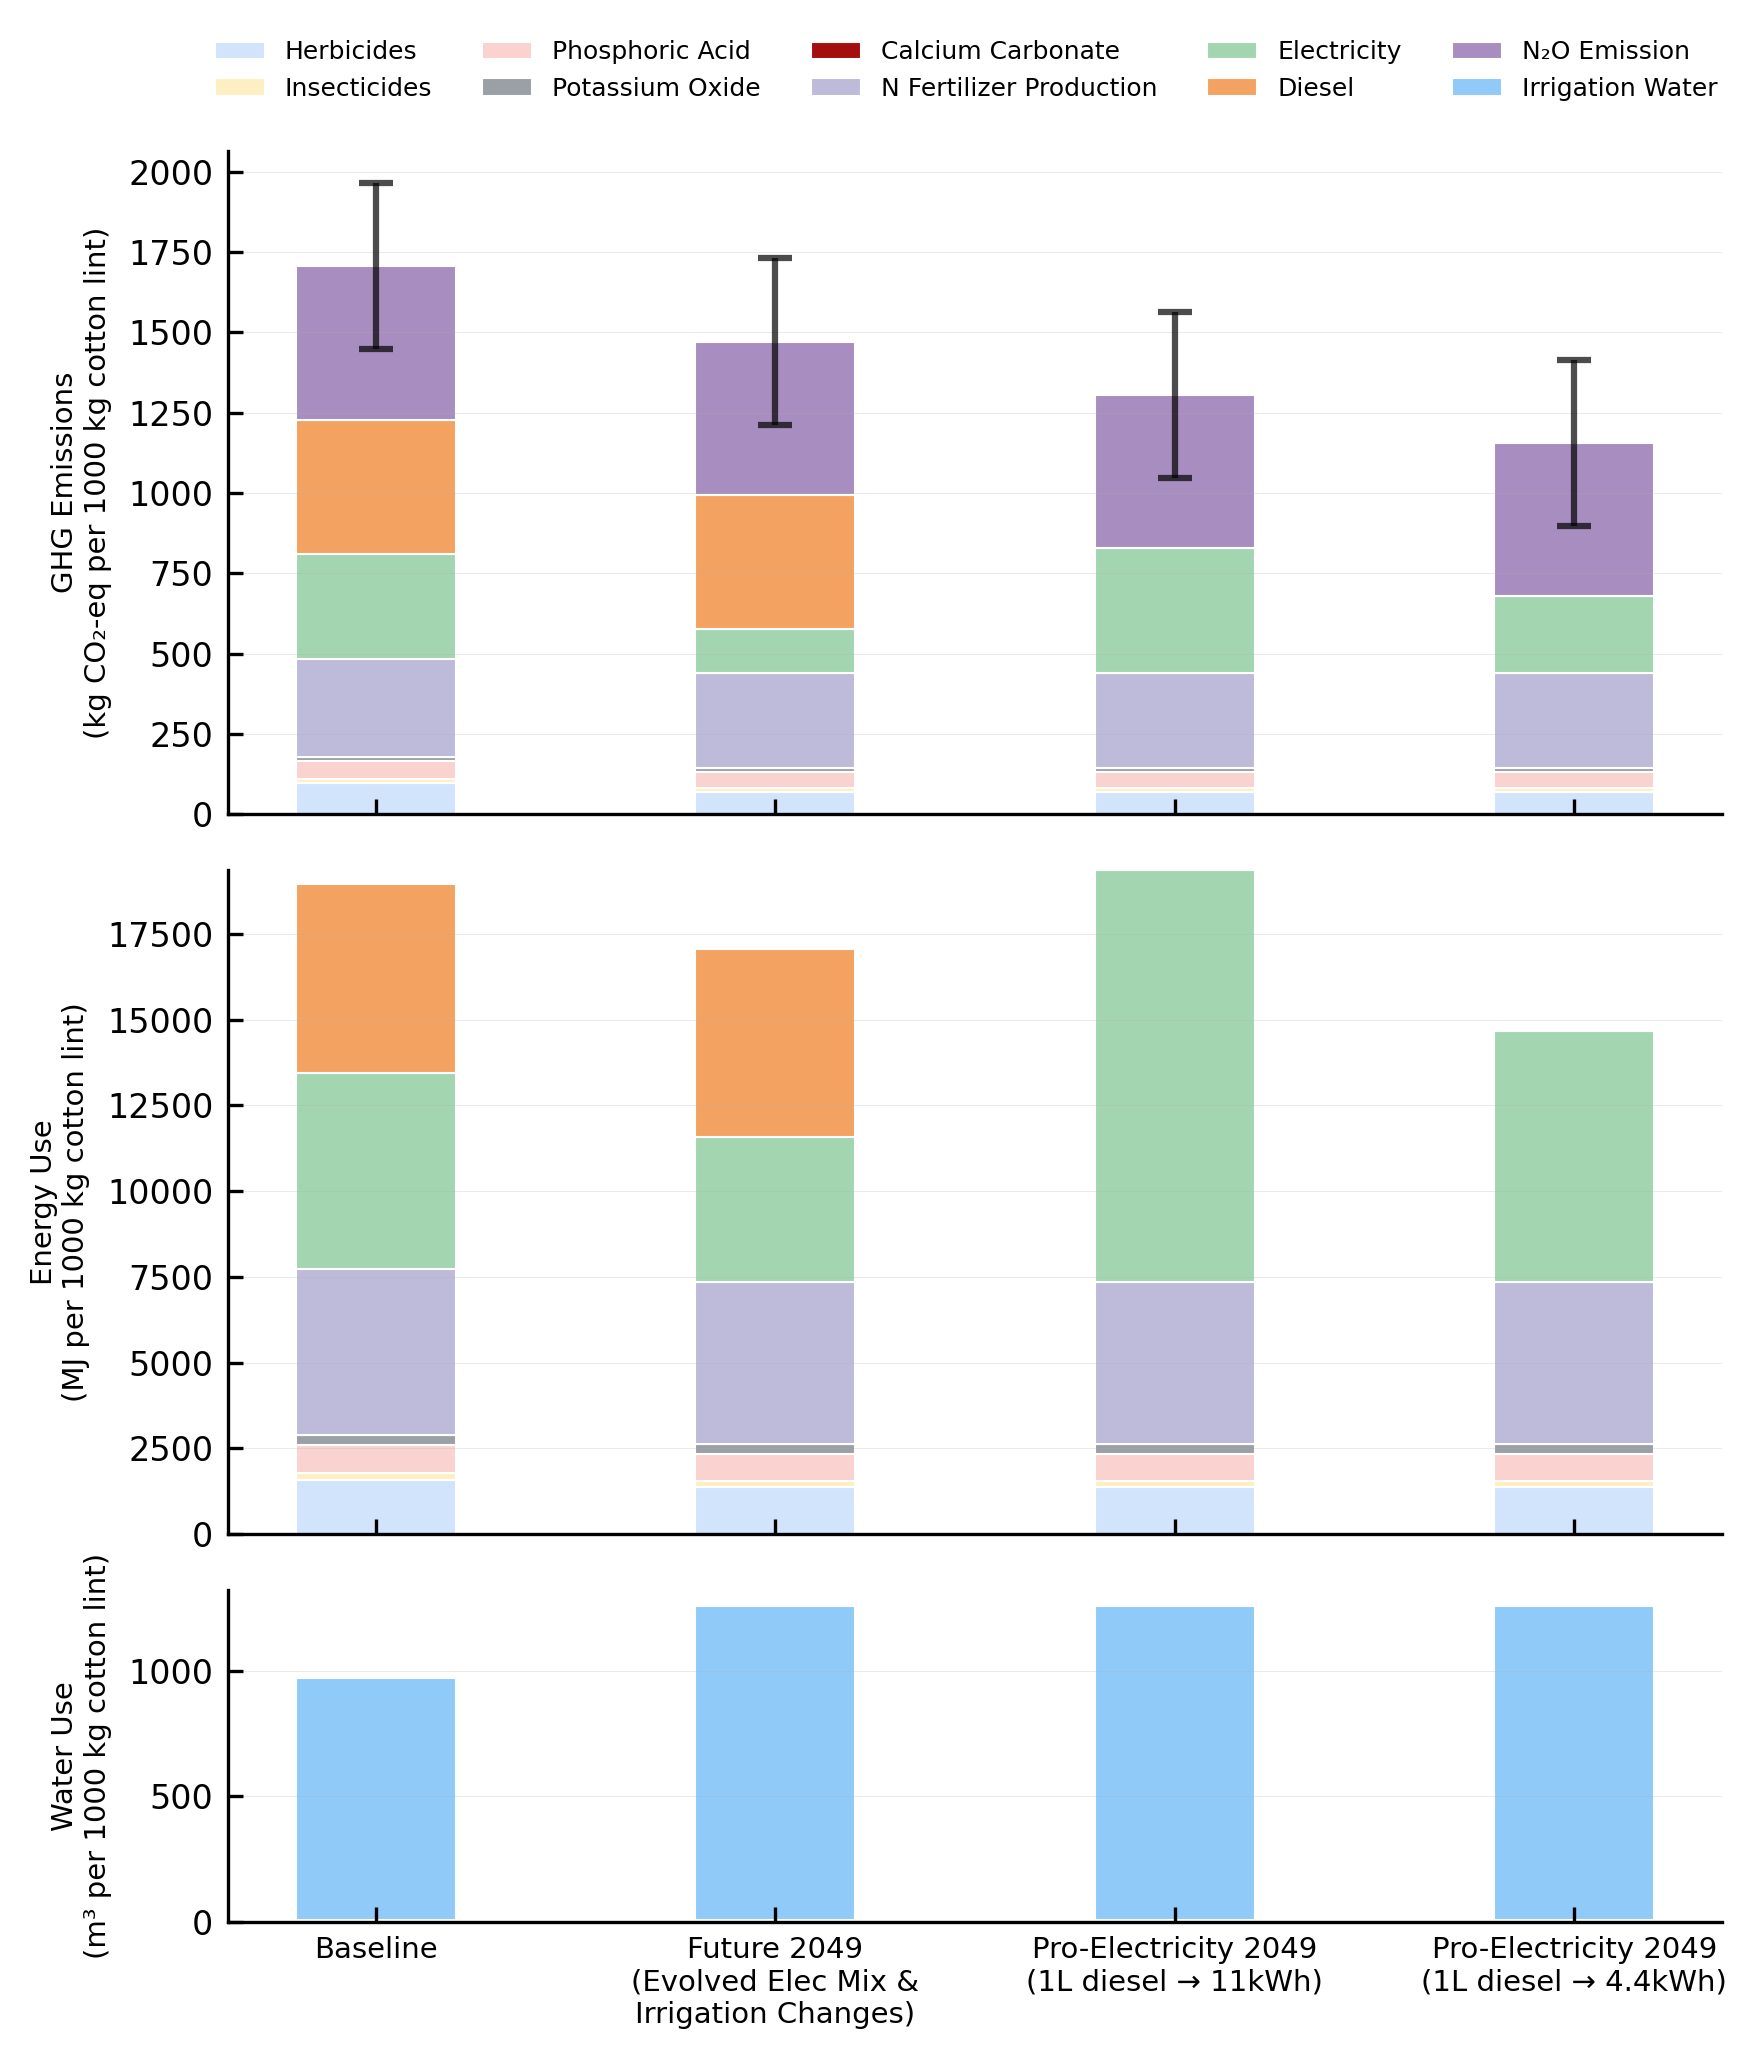

Summary Statistics (Per 1000 kg Cotton Lint):

N2O Emissions from Nitrogen Fertilizer:
Emission Factor Range: 0.8 - 2.7 kg N2O/1000kg cotton lint
Mean Emission Factor: 1.8 kg N2O/1000kg cotton lint
N2O GWP: 273 kg CO2-eq/kg N2O
N2O emissions per scenario: 477.8 ± 259.4 kg CO2-eq per 1000 kg cotton lint

Total GHG Emissions (kg CO₂-eq per 1000 kg cotton lint) - Including N2O:
Baseline: 1706.4 ± 259.4
  - Original GHG: 1228.7
  - N2O contribution: 477.8
Future 2049
(Evolved Elec Mix &
Irrigation Changes): 1470.4 ± 259.4
  - Original GHG: 992.6
  - N2O contribution: 477.8
Pro-Electricity 2049
(1L diesel → 11kWh): 1305.3 ± 259.4
  - Original GHG: 827.5
  - N2O contribution: 477.8
Pro-Electricity 2049
(1L diesel → 4.4kWh): 1156.0 ± 259.4
  - Original GHG: 678.2
  - N2O contribution: 477.8

Total Energy Use (MJ per 1000 kg cotton lint):
Baseline: 18954
Future 2049
(Evolved Elec Mix &
Irrigation Changes): 17077
Pro-Electricity 2049
(1L diesel → 11kWh): 19358
Pro-Electricity 2049
(1L diesel → 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Read the Excel file
df = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/lca_results for plot.xlsx', header=None)

# Define scenarios and their row positions with updated descriptive names
scenarios = [
    {'name': 'Baseline', 'start_row': 1},
    {'name': 'Future 2049\n(Evolved Elec Mix &\nIrrigation Changes)', 'start_row': 10},
    {'name': 'Pro-Electricity 2049\n(1L diesel → 11kWh)', 'start_row': 19},
    {'name': 'Pro-Electricity 2049\n(1L diesel → 4.4kWh)', 'start_row': 28}
]

# Categories for stacking (excluding total) - swapped nitrogen and electricity positions
categories = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
              'Calcium Carbonate', 'N Fertilizer Production', 'Electricity', 'Diesel']

# Categories for water (including irrigation water) - swapped nitrogen and electricity positions
water_categories = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
                   'Calcium Carbonate', 'N Fertilizer Production', 'Electricity', 'Diesel',
                   'Irrigation Water']

# N2O emission factors and GWP - now scaled for 1000 kg cotton lint
N2O_EF_MIN = 0.8  # kg N2O per 1000kg cotton lint (minimum)
N2O_EF_MAX = 2.7  # kg N2O per 1000kg cotton lint (maximum)
N2O_EF_MEAN = (N2O_EF_MIN + N2O_EF_MAX) / 2  # Mean emission factor
N2O_GWP = 273  # kg CO2-eq per kg N2O

# Initialize data storage
ghg_data = []
energy_data = []
water_data = []
n2o_emissions = []  # Store N2O emissions for each scenario
n2o_errors = []     # Store error ranges for N2O

# Scaling factor to convert from per kg to per 1000 kg
SCALE_FACTOR = 1000

# Extract data for each scenario
for scenario in scenarios:
    start_row = scenario['start_row']

    # GHG data (row start_row + 1, columns 2, 4, 6, 8, 10, 12, 14, 16)
    # Swapped order: columns 2, 4, 6, 8, 10, 14, 12, 16 (nitrogen before electricity)
    ghg_values = []
    column_order = [2, 4, 6, 8, 10, 14, 12, 16]  # Swapped columns 12 and 14
    for i in column_order:
        val = df.iloc[start_row + 1, i] if pd.notna(df.iloc[start_row + 1, i]) else 0
        # Convert units to kg for consistency and scale by 1000
        if i == 10:  # Calcium Carbonate is in mg
            val = val / 1000000 * SCALE_FACTOR  # mg to kg, then scale
        elif i in [2, 4, 6, 8]:  # These are in grams
            val = val / 1000 * SCALE_FACTOR  # g to kg, then scale
        else:  # Already in kg
            val = val * SCALE_FACTOR
        ghg_values.append(val)
    ghg_data.append(ghg_values)

    # Calculate N2O emissions from nitrogen fertilizer - now for 1000 kg cotton lint
    cotton_lint_kg = 1000.0  # Now calculating for 1000 kg
    n2o_emission_mean = N2O_EF_MEAN * N2O_GWP  # kg CO2-eq per 1000 kg cotton lint
    n2o_emission_min = N2O_EF_MIN * N2O_GWP
    n2o_emission_max = N2O_EF_MAX * N2O_GWP

    n2o_emissions.append(n2o_emission_mean)
    n2o_errors.append([n2o_emission_mean - n2o_emission_min, n2o_emission_max - n2o_emission_mean])

    # Energy data (row start_row + 3) - swapped order and scaled
    energy_values = []
    for i in column_order:
        val = df.iloc[start_row + 3, i] if pd.notna(df.iloc[start_row + 3, i]) else 0
        # Convert to MJ for consistency and scale by 1000
        if i == 10:  # Calcium Carbonate is in J
            val = val / 1000000 * SCALE_FACTOR  # J to MJ, then scale
        elif i in [2, 4, 6, 8, 12, 14, 16]:  # These are in kJ
            val = val / 1000 * SCALE_FACTOR  # kJ to MJ, then scale
        else:  # Already in MJ
            val = val * SCALE_FACTOR
        energy_values.append(val)
    energy_data.append(energy_values)

    # Water data (row start_row + 5) - including irrigation water, swapped order and scaled
    water_values = []
    water_column_order = [2, 4, 6, 8, 10, 14, 12, 16, 18]  # Added column 18 for irrigation water
    for i in water_column_order:
        val = df.iloc[start_row + 5, i] if pd.notna(df.iloc[start_row + 5, i]) else 0
        # Convert to m³ for consistency and scale by 1000
        if i in [2, 4, 6, 8, 10, 12, 14, 16]:  # These are in cm³
            val = val / 1000000 * SCALE_FACTOR  # cm³ to m³, then scale
        else:  # Column 18 (irrigation water) is already in m³
            val = val * SCALE_FACTOR
        water_values.append(val)
    water_data.append(water_values)

# Convert to numpy arrays for easier plotting
ghg_data = np.array(ghg_data).T
energy_data = np.array(energy_data).T
water_data = np.array(water_data).T
n2o_emissions = np.array(n2o_emissions)
n2o_errors = np.array(n2o_errors).T

# Create the plot with journal-appropriate styling
fig, axes = plt.subplots(3, 1, figsize=(7.2, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
# fig.suptitle('Environmental Impact Assessment of Cotton Production Scenarios',
#              fontsize=14, fontweight='bold', y=0.98)

# Professional color mapping for journal publication
def get_color_mapping():
    """Professional color scheme suitable for journal papers with clear distinction and accessibility"""
    color_map = {
        # Main contributors - distinct, saturated colors (swapped nitrogen and electricity)
        'Electricity': '#A4D5B1',
        'N Fertilizer Production': '#BEBADA',
        'N₂O Emission': '#A88EC0',
        'Diesel': '#F4A261',

        # Chemical inputs - muted professional colors
        'Herbicides': '#D2E3FC',            # Purple
        'Insecticides': '#FEEFC3',          # Red
        'Phosphoric Acid': '#FAD2CF',       # Brown
        'Potassium Oxide': '#9AA0A6',       # Blue grey
        'Calcium Carbonate': '#A50E0E',     # Grey

        # Water - blue theme
        'Irrigation Water': '#90CAF9'       # Water blue
    }
    return color_map
cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
print(colors)

# '#A4D5B1'
# '#A88EC0'
# '#F4A261'

color_mapping = get_color_mapping()

# Create color lists for plotting
colors = [color_mapping[cat] for cat in categories]
water_colors = [color_mapping[cat] for cat in water_categories]

# Scenario names for x-axis
scenario_names = [s['name'] for s in scenarios]
x_pos = np.arange(len(scenario_names))

# Set bar width (default is 0.8, reduce for narrower bars)
bar_width = 0.4  # Adjust this value: smaller = narrower bars

# Plot 1: GHG Emissions (including N2O from nitrogen)
bottom_ghg = np.zeros(len(scenario_names))
bars_ghg = []

# Plot original categories with refined styling
for i, (category, color) in enumerate(zip(categories, colors)):
    bars = axes[0].bar(x_pos, ghg_data[i], bottom=bottom_ghg, label=category,
                      color=color, alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
    bars_ghg.append(bars)
    bottom_ghg += ghg_data[i]

# Add N2O emissions as a separate category
n2o_bars = axes[0].bar(x_pos, n2o_emissions, bottom=bottom_ghg,
                       label='N₂O Emission', color=color_mapping['N₂O Emission'],
                       alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
bars_ghg.append(n2o_bars)

# Add error bars for total emissions (including N2O uncertainty)
total_ghg = np.sum(ghg_data, axis=0) + n2o_emissions
axes[0].errorbar(x_pos, total_ghg, yerr=n2o_errors, fmt='none', ecolor='black',
                capsize=4, capthick=1.5, linewidth=1.5, alpha=0.7)

# axes[0].set_title('(a) Greenhouse Gas Emissions', fontsize=12, fontweight='bold', pad=15)
axes[0].set_ylabel('GHG Emissions\n(kg CO₂-eq per 1000 kg cotton lint)', fontsize=7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(scenario_names, rotation=0, ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3, linewidth=0.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2: Energy Use
bottom_energy = np.zeros(len(scenario_names))
for i, (category, color) in enumerate(zip(categories, colors)):
    axes[1].bar(x_pos, energy_data[i], bottom=bottom_energy, color=color,
               alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
    bottom_energy += energy_data[i]

# axes[1].set_title('(b) Energy Consumption', fontsize=12, fontweight='bold', pad=15)
axes[1].set_ylabel('Energy Use\n(MJ per 1000 kg cotton lint)', fontsize=7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(scenario_names, rotation=0, ha='center', fontsize=8)
axes[1].grid(axis='y', alpha=0.3, linewidth=0.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Plot 3: Water Use (including irrigation water)
bottom_water = np.zeros(len(scenario_names))
for i, (category, color) in enumerate(zip(water_categories, water_colors)):
    axes[2].bar(x_pos, water_data[i], bottom=bottom_water, color=color,
               alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
    bottom_water += water_data[i]

# axes[2].set_title('(c) Water Consumption', fontsize=12, fontweight='bold', pad=15)
axes[2].set_ylabel('Water Use\n(m³ per 1000 kg cotton lint)', fontsize=7)
# axes[2].set_xlabel('Production Scenarios', fontsize=8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(scenario_names, rotation=0, ha='center', fontsize=7)
axes[2].grid(axis='y', alpha=0.3, linewidth=0.2)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

# Create a common legend for all subplots at the top
# Collect all unique categories across plots
all_categories = categories + ['N₂O Emission'] + ['Irrigation Water']
all_colors = [color_mapping[cat] for cat in all_categories]

# Create legend handles
legend_handles = [plt.Rectangle((0,0),1,1, facecolor=color, edgecolor='white', linewidth=0.5)
                 for color in all_colors]

# Position the common legend at the top of the figure
fig.legend(legend_handles, all_categories, loc='upper center', bbox_to_anchor=(0.45, 1.05),
          fontsize=6, frameon=False, fancybox=True, shadow=False, ncol=5)

# Adjust layout to prevent overlap
plt.tight_layout()

plt.subplots_adjust(right=0.8)  # Make room for legends
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_results.tiff', dpi=300, bbox_inches='tight')
# Display the plot
plt.show()

# Optional: Save the plot
# plt.savefig('lca_results_comparison_with_n2o_per_1000kg.png', dpi=300, bbox_inches='tight')

# Print summary statistics - updated for 1000 kg
print("Summary Statistics (Per 1000 kg Cotton Lint):")
print("\nN2O Emissions from Nitrogen Fertilizer:")
print(f"Emission Factor Range: {N2O_EF_MIN:.1f} - {N2O_EF_MAX:.1f} kg N2O/1000kg cotton lint")
print(f"Mean Emission Factor: {N2O_EF_MEAN:.1f} kg N2O/1000kg cotton lint")
print(f"N2O GWP: {N2O_GWP} kg CO2-eq/kg N2O")
print(f"N2O emissions per scenario: {n2o_emissions[0]:.1f} ± {(n2o_errors[1,0] + n2o_errors[0,0])/2:.1f} kg CO2-eq per 1000 kg cotton lint")

print("\nTotal GHG Emissions (kg CO₂-eq per 1000 kg cotton lint) - Including N2O:")
for i, scenario in enumerate(scenario_names):
    total_without_n2o = np.sum(ghg_data[:, i])
    total_with_n2o = total_without_n2o + n2o_emissions[i]
    error_range = n2o_errors[1,i] + n2o_errors[0,i]
    print(f"{scenario}: {total_with_n2o:.1f} ± {error_range/2:.1f}")
    print(f"  - Original GHG: {total_without_n2o:.1f}")
    print(f"  - N2O contribution: {n2o_emissions[i]:.1f}")

print("\nTotal Energy Use (MJ per 1000 kg cotton lint):")
for i, scenario in enumerate(scenario_names):
    print(f"{scenario}: {np.sum(energy_data[:, i]):.0f}")

print("\nTotal Water Use (m³ per 1000 kg cotton lint):")
for i, scenario in enumerate(scenario_names):
    print(f"{scenario}: {np.sum(water_data[:, i]):.1f}")